In [2]:
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import RemoveMessage,HumanMessage

In [3]:
load_dotenv()

True

In [4]:
model=ChatOpenAI(model='gpt-4o-mini')

In [5]:
class ChatState(MessagesState):
    summary: str# to store summary 

In [7]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)# summary of all msgs

    
    messages_to_delete = state["messages"][:-2]# keeping only last two

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [20]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [21]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [22]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [23]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

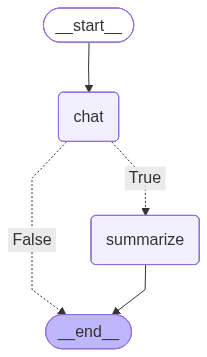

In [24]:

graph

In [25]:
config = {"configurable": {"thread_id": "t1"}}

In [26]:

def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [27]:
def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [28]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='b6c0485f-5c1b-4a0c-987e-88c9ec5a0427')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame


In [29]:
run_turn('Black Hole')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='b6c0485f-5c1b-4a0c-987e-88c9ec5a0427'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. It emerged in the early 20th century, fundamentally changing our understanding of how nature works. Here are some key concepts and principles of quantum physics:\n\n1. **Wave-Particle Duality**: Particles, such as electrons and photons, exhibit both wave-like and particle-like properties. For instance, light can behave like a wave (interference patterns) and a particle (photons).\n\n2. **Quantum States**: The state of a quantum system is described by a wave function, which encapsulates all the information about the system. The wave function evolves according to the Schrödinger equation.\n\n3. **Superposition**: Quantum systems ca

In [ ]:
run_turn('Black Hole and qunatum physics and their relation with einstein ')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='b6c0485f-5c1b-4a0c-987e-88c9ec5a0427'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. It emerged in the early 20th century, fundamentally changing our understanding of how nature works. Here are some key concepts and principles of quantum physics:\n\n1. **Wave-Particle Duality**: Particles, such as electrons and photons, exhibit both wave-like and particle-like properties. For instance, light can behave like a wave (interference patterns) and a particle (photons).\n\n2. **Quantum States**: The state of a quantum system is described by a wave function, which encapsulates all the information about the system. The wave function evolves according to the Schrödinger equation.\n\n3. **Superposition**: Quantum systems ca

In [31]:
run_turn('white holes and their relation with einstein')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='b6c0485f-5c1b-4a0c-987e-88c9ec5a0427'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. It emerged in the early 20th century, fundamentally changing our understanding of how nature works. Here are some key concepts and principles of quantum physics:\n\n1. **Wave-Particle Duality**: Particles, such as electrons and photons, exhibit both wave-like and particle-like properties. For instance, light can behave like a wave (interference patterns) and a particle (photons).\n\n2. **Quantum States**: The state of a quantum system is described by a wave function, which encapsulates all the information about the system. The wave function evolves according to the Schrödinger equation.\n\n3. **Superposition**: Quantum systems ca